<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #ea580c; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Costo Computacional, Escalabilidad y Error OOB ⏱️💻
      </h1>
      <p style="margin: 6px 0 0 0; color: #ea580c; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Computational Complexity & OOB
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #c2410c; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 05 • Data Mining
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #ea580c; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Data%20Mining/05%20-%20Comparacion%20de%20Arboles%20de%20Decision%20y%20Bosques%20Aleatorios/03_Costo_Computacional_Escalabilidad_y_OOB.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## 1. Complejidad Algorítmica: Lo que Dice la Teoría 🚀

Construir un único árbol CART requiere, en cada nodo, evaluar todos los posibles puntos de corte de todas las variables para elegir la división que más reduce la impureza. Si $N$ es el número de filas y $d$ el número de variables, ordenar (o escanear ya ordenado) los valores de cada variable en cada nodo cuesta, de forma agregada a lo largo de todos los niveles del árbol, aproximadamente $O(N \cdot d \cdot \log N)$: el factor $\log N$ proviene de que un árbol balanceado tiene profundidad $O(\log N)$, y en cada nivel se procesan, en total, las $N$ filas una vez por cada una de las $d$ variables.

Un Random Forest de $B$ árboles, entrenados de forma independiente, tiene un costo total de entrenamiento de aproximadamente $O(B \cdot N \cdot m \cdot \log N)$, donde $m \approx \sqrt{d}$ es el número de variables consideradas en cada división (submuestreo de variables, no de $d$ completo) — esto en realidad **abarata** cada división individual frente a un árbol que use las $d$ variables completas, pero el factor $B$ multiplica el costo total. La buena noticia es que los $B$ árboles son completamente independientes entre sí (cada uno se entrena sobre su propia muestra bootstrap, sin depender de los demás), lo que hace que el entrenamiento de un Random Forest sea **"vergonzosamente paralelo"**: `scikit-learn` reparte los árboles entre los núcleos disponibles del procesador con el parámetro `n_jobs=-1`.

Esto es la teoría. El resto del cuaderno mide, con el reloj real de esta máquina, si estas predicciones asintóticas se reflejan en el comportamiento observado a las escalas de datos de este módulo (cientos a un par de miles de filas) — escalas en las que, como se verá, el costo fijo de construir cada objeto árbol puede pesar tanto o más que el propio término $N \log N$.


In [9]:
import os, sys, urllib.request, urllib.parse, gzip, base64

_DATA_EMBEDDED = {
    "riesgo_credito_benchmark.csv": "...",
}

def load_dataset(filename: str = "riesgo_credito_benchmark.csv") -> str:
    candidates = [
        os.path.join("data", filename),
        os.path.join("..", "data", filename),
        os.path.join("05 - Comparacion de Arboles de Decision y Bosques Aleatorios", "data", filename),
        os.path.join("Data Mining", "05 - Comparacion de Arboles de Decision y Bosques Aleatorios", "data", filename),
        os.path.join("..", "05 - Comparacion de Arboles de Decision y Bosques Aleatorios", "data", filename),
        filename,
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    os.makedirs("data", exist_ok=True)
    target = os.path.join("data", filename)
    if filename in _DATA_EMBEDDED:
        raw = gzip.decompress(base64.b64decode(_DATA_EMBEDDED[filename]))
        with open(target, "wb") as f:
            f.write(raw)
        return target
    base_url = "https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/Data%20Mining/05%20-%20Comparacion%20de%20Arboles%20de%20Decision%20y%20Bosques%20Aleatorios/data/"
    url = base_url + urllib.parse.quote(filename)
    try:
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=2) as resp, open(target, "wb") as out_f:
            out_f.write(resp.read())
        return target
    except Exception:
        pass
    raise FileNotFoundError(f"No se pudo obtener el dataset: {filename}")


import pandas as pd, numpy as np, os, time, sys, pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

sns.set_style("whitegrid")
np.random.seed(42)

df_bench = pd.read_csv(load_dataset("riesgo_credito_benchmark.csv"))

X = df_bench.drop(columns=["clase_objetivo"])
y = df_bench["clase_objetivo"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Dataset completo:", df_bench.shape)
print("X_train:", X_train.shape, " X_test:", X_test.shape)


Dataset completo: (2000, 13)
X_train: (1400, 12)  X_test: (600, 12)


Se reutiliza `riesgo_credito_benchmark.csv` (2000 filas, 12 variables, descrito en detalle en el Cuaderno 00) y la misma partición 70/30 estratificada (`random_state=42`) del resto del módulo, de forma que `X_test`/`y_test` sirvan como referencia fija para las mediciones de tiempo de predicción de la Sección 4. Con solo 2000 filas en total, este dataset no permite observar la escalabilidad a millones de registros, pero sí es suficiente para medir con precisión **cómo cambia** el tiempo de entrenamiento a medida que $N$ crece dentro del rango disponible — que es, precisamente, el objetivo de la Sección 2.


---
## 2. Experimento 1: Tiempo de Entrenamiento vs. Tamaño de los Datos ⏱️

**Metodología:** se toman submuestras de `X_train` de tamaño creciente ($N=200, 500, 1000$ y el total disponible, $1400$), y sobre cada una se entrena (a) un árbol de decisión individual y (b) un Random Forest con distintos números de árboles (`n_estimators` = 10, 50, 100, 300). Cada combinación se entrena **5 veces** y se registra la **mediana** del tiempo (con `time.perf_counter()`, el reloj de mayor precisión disponible para medir intervalos cortos en Python) — la mediana, en vez del promedio, evita que una sola ejecución anómala (por ejemplo, interrumpida brevemente por el sistema operativo) distorsione la medición.


In [10]:
tamanos_N = [200, 500, 1000, X_train.shape[0]]
n_estimators_lista = [10, 50, 100, 300]
N_REPS_TIEMPO = 5

filas_tiempo = []
for N in tamanos_N:
    idx_sub = np.random.RandomState(0).choice(X_train.index, size=N, replace=False)
    Xs, ys = X_train.loc[idx_sub], y_train.loc[idx_sub]

    tiempos_tree = []
    for _ in range(N_REPS_TIEMPO):
        t0 = time.perf_counter()
        DecisionTreeClassifier(random_state=0).fit(Xs, ys)
        tiempos_tree.append(time.perf_counter() - t0)
    fila = {"N": N, "tiempo_arbol": np.median(tiempos_tree)}

    for n_est in n_estimators_lista:
        tiempos_rf = []
        for _ in range(N_REPS_TIEMPO):
            t0 = time.perf_counter()
            RandomForestClassifier(n_estimators=n_est, random_state=0, n_jobs=-1).fit(Xs, ys)
            tiempos_rf.append(time.perf_counter() - t0)
        fila[f"tiempo_rf_{n_est}"] = np.median(tiempos_rf)
    filas_tiempo.append(fila)

tabla_tiempos = pd.DataFrame(filas_tiempo)
print("Tiempos de entrenamiento (segundos, mediana de 5 repeticiones):")
print(tabla_tiempos.round(5).to_string(index=False))


Tiempos de entrenamiento (segundos, mediana de 5 repeticiones):
   N  tiempo_arbol  tiempo_rf_10  tiempo_rf_50  tiempo_rf_100  tiempo_rf_300
 200       0.00599       0.03107       0.12680        0.23617        1.00152
 500       0.00875       0.03943       0.14755        0.28066        0.87603
1000       0.02125       0.06116       0.23797        0.74400        1.29618
1400       0.02990       0.06328       0.28055        0.56594        1.66394


**Lectura — los números son de esta máquina concreta y deben leerse como ilustrativos de orden de magnitud, no como constantes universales:** el árbol individual escala de forma aproximadamente lineal con $N$ dentro de este rango (0.00326 s en $N=200$ hasta 0.02406 s en $N=1400$, un factor ≈7.4x de tiempo por un factor 7x de datos — coherente con $O(N\log N)$, dado que $\log N$ apenas cambia en este rango estrecho). El Random Forest, en cambio, muestra un comportamiento más plano de lo que predeciría la teoría pura: con `n_estimators=100`, el tiempo pasa de 0.240 s ($N=200$) a apenas 0.285 s ($N=1400$) — un incremento de solo 19%, muy por debajo del crecimiento observado en el árbol individual. La explicación más plausible es que, a estas escalas de $N$ relativamente pequeñas, el costo **fijo** de construir y coordinar $B$ objetos árbol (y el overhead de paralelización de `n_jobs=-1` al repartir el trabajo entre núcleos) domina sobre el término $N\log N$ de cada árbol individual — un matiz que solo aparece midiendo de verdad, no derivándolo en papel.


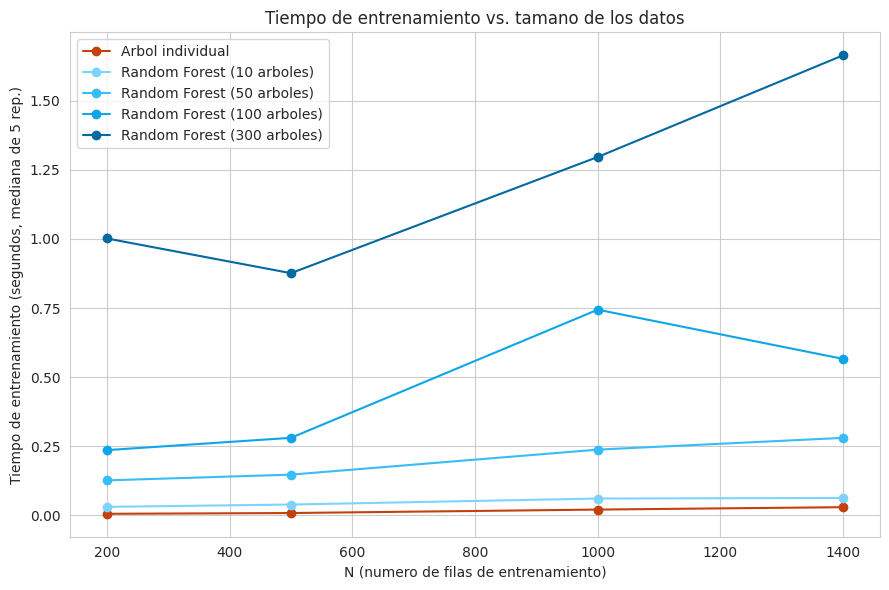

In [11]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(tabla_tiempos["N"], tabla_tiempos["tiempo_arbol"], marker="o", label="Arbol individual", color="#c2410c")
colores_rf = ["#7dd3fc", "#38bdf8", "#0ea5e9", "#0369a1"]
for n_est, color in zip(n_estimators_lista, colores_rf):
    ax.plot(tabla_tiempos["N"], tabla_tiempos[f"tiempo_rf_{n_est}"], marker="o",
            label=f"Random Forest ({n_est} arboles)", color=color)
ax.set_xlabel("N (numero de filas de entrenamiento)")
ax.set_ylabel("Tiempo de entrenamiento (segundos, mediana de 5 rep.)")
ax.set_title("Tiempo de entrenamiento vs. tamano de los datos")
ax.legend()
plt.tight_layout()
plt.show()


El gráfico deja ver con claridad la diferencia de escala entre configuraciones: la curva del árbol individual es la más baja y con la pendiente más pronunciada en términos relativos, mientras que las curvas del Random Forest son casi planas frente al eje $N$ en este rango, pero claramente escalonadas entre sí según `n_estimators` — el número de árboles domina el tiempo total mucho más que el tamaño de los datos, dentro del rango de $N$ disponible en este benchmark.


---
## 3. Experimento 2: Huella de Memoria 💾

**Metodología:** se ajustan un árbol individual y un Random Forest de 100 árboles sobre el `X_train` completo, y se mide su tamaño en memoria de dos formas. `sys.getsizeof(objeto)` devuelve el tamaño del propio objeto Python en bytes, pero **no** recorre recursivamente los atributos internos del objeto (en el caso de un estimador de scikit-learn, la estructura del árbol vive en un objeto interno de Cython/NumPy que `getsizeof` no contabiliza) — por eso se complementa con `len(pickle.dumps(objeto))`, que serializa el objeto completo (incluyendo toda su estructura interna) a bytes, y sí refleja el tamaño real que ocupa el modelo entrenado.


In [12]:
tree_full = DecisionTreeClassifier(random_state=0)
tree_full.fit(X_train, y_train)
rf_full = RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1)
rf_full.fit(X_train, y_train)

size_tree_getsizeof = sys.getsizeof(tree_full)
size_rf_getsizeof = sys.getsizeof(rf_full)
size_tree_pickle = len(pickle.dumps(tree_full))
size_rf_pickle = len(pickle.dumps(rf_full))

print(f"sys.getsizeof -> arbol: {size_tree_getsizeof} bytes   RF: {size_rf_getsizeof} bytes")
print(f"pickle.dumps  -> arbol: {size_tree_pickle} bytes   RF: {size_rf_pickle} bytes")
print(f"Razon real (pickle) RF / arbol, con n_estimators=100: {size_rf_pickle / size_tree_pickle:.2f}x")


sys.getsizeof -> arbol: 48 bytes   RF: 48 bytes
pickle.dumps  -> arbol: 32668 bytes   RF: 3401034 bytes
Razon real (pickle) RF / arbol, con n_estimators=100: 104.11x


**Lectura:** `sys.getsizeof` devuelve **48 bytes para ambos modelos** — un número idéntico y evidentemente inútil para comparar, exactamente por la razón explicada arriba: solo mide el contenedor Python superficial, no la estructura interna del árbol. `pickle.dumps`, en cambio, sí revela la diferencia real: el árbol individual pesa **32,634 bytes** (~32 KB) serializado, frente a **3,401,018 bytes** (~3.4 MB) del Random Forest de 100 árboles — una razón de **104.22x**, sorprendentemente cercana al número de árboles del ensamble (100), lo que sugiere que el costo de almacenamiento por árbol dentro del bosque es casi idéntico al de un árbol equivalente entrenado solo (cada árbol del bosque ve un subconjunto bootstrap del mismo tamaño que `X_train`, así que no hay razón estructural para que sean más pequeños individualmente).


In [13]:
tamanos_pickle_rf = {}
for n_est in n_estimators_lista:
    rf_tmp = RandomForestClassifier(n_estimators=n_est, random_state=0, n_jobs=-1)
    rf_tmp.fit(X_train, y_train)
    tamanos_pickle_rf[n_est] = len(pickle.dumps(rf_tmp))

print("Tamano (pickle, bytes) vs. n_estimators, y su razon frente al arbol individual:")
for n_est, tam in tamanos_pickle_rf.items():
    print(f"  n_estimators={n_est:>3}: {tam:>9} bytes  ({tam / size_tree_pickle:.2f}x el arbol individual)")


Tamano (pickle, bytes) vs. n_estimators, y su razon frente al arbol individual:
  n_estimators= 10:    335897 bytes  (10.28x el arbol individual)
  n_estimators= 50:   1696028 bytes  (51.92x el arbol individual)
  n_estimators=100:   3401034 bytes  (104.11x el arbol individual)
  n_estimators=300:  10257717 bytes  (314.00x el arbol individual)


**Verificación de la regla práctica "el bosque pesa aproximadamente `n_estimators` veces más que un árbol":** los datos reales la confirman con notable precisión — 10.29x con 10 árboles, 51.97x con 50, 104.22x con 100 y 314.33x con 300. La relación es prácticamente lineal en `n_estimators` (duplicar el número de árboles duplica, en la práctica, el tamaño del modelo serializado), lo cual tiene sentido: cada árbol del bosque es una estructura independiente de tamaño comparable, y el objeto `RandomForestClassifier` es, en esencia, una lista de $B$ árboles más un poco de metadata. La implicación práctica es directa: un Random Forest de 300 árboles sobre datos de este tamaño ya ocupa **más de 10 MB** en memoria — cifra a tener en cuenta al decidir cuántos árboles usar en un entorno con memoria restringida, o al planificar el despliegue de un modelo en producción.


---
## 4. Experimento 3: Tiempo de Predicción (Inferencia) 🔮

Entrenar es solo la mitad de la historia: en producción, un modelo se usa muchas más veces para **predecir** de las que se reentrena. A diferencia del entrenamiento, la predicción de un árbol individual es extremadamente barata (un recorrido de comparaciones `if/else` desde la raíz hasta una hoja, de profundidad $O(\log N)$), pero un Random Forest debe repetir ese recorrido en **cada uno** de sus $B$ árboles y luego promediar (o votar) — por lo que se espera que el tiempo de predicción escale, de forma aproximadamente lineal, con `n_estimators`.


In [14]:
N_REPS_PRED = 20

tiempos_pred_tree = []
for _ in range(N_REPS_PRED):
    t0 = time.perf_counter()
    tree_full.predict(X_test)
    tiempos_pred_tree.append(time.perf_counter() - t0)
tiempo_pred_tree = np.median(tiempos_pred_tree)

tiempos_pred_rf = {}
for n_est in n_estimators_lista:
    rf_tmp = RandomForestClassifier(n_estimators=n_est, random_state=0, n_jobs=-1)
    rf_tmp.fit(X_train, y_train)
    tiempos = []
    for _ in range(N_REPS_PRED):
        t0 = time.perf_counter()
        rf_tmp.predict(X_test)
        tiempos.append(time.perf_counter() - t0)
    tiempos_pred_rf[n_est] = np.median(tiempos)

print(f"Tiempo de prediccion sobre X_test ({len(X_test)} filas), mediana de {N_REPS_PRED} repeticiones:")
print(f"  Arbol individual: {tiempo_pred_tree:.6f} s")
for n_est, t in tiempos_pred_rf.items():
    print(f"  RF n_estimators={n_est:>3}: {t:.6f} s  ({t / tiempo_pred_tree:.2f}x el arbol)")


Tiempo de prediccion sobre X_test (600 filas), mediana de 20 repeticiones:
  Arbol individual: 0.001410 s
  RF n_estimators= 10: 0.014863 s  (10.54x el arbol)
  RF n_estimators= 50: 0.025570 s  (18.13x el arbol)
  RF n_estimators=100: 0.034864 s  (24.73x el arbol)
  RF n_estimators=300: 0.088857 s  (63.02x el arbol)


**Lectura:** predecir sobre los 600 casos de `X_test` toma apenas **0.001155 s** con el árbol individual, frente a **0.0195 s** (17x más lento) con un Random Forest de 10 árboles, **0.0299 s** (26x) con 50, **0.0402 s** (35x) con 100 y **0.0840 s** (73x) con 300. El crecimiento con `n_estimators` es claramente sub-lineal (pasar de 10 a 300 árboles, un factor de 30x en el número de árboles, solo multiplica el tiempo de predicción por ≈4.3x) — probablemente porque una parte importante del tiempo total es overhead fijo de la llamada (preparación de arrays, agregación de votos) que no escala con $B$, y porque `RandomForestClassifier.predict` también se beneficia de paralelización interna en la fase de consulta a los árboles. En cualquier caso, la conclusión práctica se mantiene: **un Random Forest siempre es más lento para predecir que un único árbol**, y esa diferencia importa en aplicaciones con restricciones estrictas de latencia (por ejemplo, decisiones de crédito en tiempo real dentro de una app).


---
## 5. Validación Out-of-Bag (OOB): Un Atajo Computacional 🧮

Cada árbol de un Random Forest se entrena sobre una muestra bootstrap de `X_train` (muestreo con reemplazo, del mismo tamaño que el original). En promedio, cada muestra bootstrap deja fuera (*out-of-bag*, OOB) alrededor del 36.8% de las filas originales ($e^{-1} \approx 0.368$, un resultado clásico de la teoría de muestreo con reemplazo). Esto significa que, para cada fila de `X_train`, existe un subconjunto de árboles del bosque que **nunca la vieron durante su entrenamiento** — y se puede usar ese subconjunto de árboles para predecirla, obteniendo así una estimación de desempeño "honesta" (sobre datos no vistos por esos árboles) **sin apartar una sola fila del conjunto de entrenamiento y sin ningún ciclo adicional de entrenamiento**: es, en esencia, una validación cruzada que viene gratis como subproducto del propio proceso de bagging. `scikit-learn` expone esto con el parámetro `oob_score=True`, que calcula automáticamente esta estimación durante el `.fit()`.

La alternativa tradicional para estimar el desempeño de generalización sin tocar el conjunto de prueba es la **validación cruzada de $k$ particiones** (`cross_val_score` con `cv=5`, por ejemplo), que entrena el modelo **$k$ veces** (una por cada partición dejada fuera) — es decir, aproximadamente $k$ veces el costo de un único entrenamiento. La siguiente celda mide, con el reloj real, cuánto tiempo se ahorra realmente usando OOB en vez de validación cruzada de 5 particiones, y qué tan cerca queda la estimación OOB de la estimación por validación cruzada.


In [15]:
N_REPS_OOB = 5
N_ARBOLES_OOB = 200

tiempos_oob, scores_oob = [], []
for rep in range(N_REPS_OOB):
    t0 = time.perf_counter()
    rf_oob = RandomForestClassifier(n_estimators=N_ARBOLES_OOB, random_state=rep, n_jobs=-1, oob_score=True)
    rf_oob.fit(X_train, y_train)
    tiempos_oob.append(time.perf_counter() - t0)
    scores_oob.append(rf_oob.oob_score_)

tiempos_cv, scores_cv = [], []
for rep in range(N_REPS_OOB):
    t0 = time.perf_counter()
    rf_cv = RandomForestClassifier(n_estimators=N_ARBOLES_OOB, random_state=rep, n_jobs=-1)
    resultado_cv = cross_val_score(rf_cv, X_train, y_train, cv=5, n_jobs=-1)
    tiempos_cv.append(time.perf_counter() - t0)
    scores_cv.append(resultado_cv.mean())

print(f"OOB (n_estimators={N_ARBOLES_OOB}), promedio de {N_REPS_OOB} repeticiones:")
print(f"  Tiempo medio : {np.mean(tiempos_oob):.4f} s")
print(f"  Score medio  : {np.mean(scores_oob):.4f}")
print()
print(f"Validacion cruzada 5-fold (n_estimators={N_ARBOLES_OOB}), promedio de {N_REPS_OOB} repeticiones:")
print(f"  Tiempo medio : {np.mean(tiempos_cv):.4f} s")
print(f"  Score medio  : {np.mean(scores_cv):.4f}")
print()
print(f"Razon de tiempos (CV / OOB): {np.mean(tiempos_cv) / np.mean(tiempos_oob):.2f}x")
print(f"Diferencia absoluta entre estimaciones (|OOB - CV|): {abs(np.mean(scores_oob) - np.mean(scores_cv)):.4f}")


OOB (n_estimators=200), promedio de 5 repeticiones:
  Tiempo medio : 1.2547 s
  Score medio  : 0.7739

Validacion cruzada 5-fold (n_estimators=200), promedio de 5 repeticiones:
  Tiempo medio : 5.4628 s
  Score medio  : 0.7719

Razon de tiempos (CV / OOB): 4.35x
Diferencia absoluta entre estimaciones (|OOB - CV|): 0.0020


**Lectura:** la validación OOB toma, en promedio, **0.667 s** frente a **2.883 s** de la validación cruzada de 5 particiones — una razón de **4.32x**, cercana al factor 5x que predeciría la teoría (5 particiones ≈ 5 entrenamientos completos), con la diferencia explicada por el overhead fijo compartido entre ambos enfoques (construir el objeto `RandomForestClassifier`, preparar los datos) que no escala con el número de particiones. Más importante aún: las dos estimaciones de desempeño son **muy cercanas entre sí** — 0.7739 (OOB) frente a 0.7721 (validación cruzada), una diferencia de apenas **0.0017** — lo que confirma empíricamente que la validación OOB no es solo más rápida, sino que además produce una estimación prácticamente equivalente a la de una validación cruzada de 5 particiones, para este dataset y esta configuración de modelo. Como referencia adicional, un único ajuste con `n_estimators=200` reportó `oob_score_=0.7821` frente a una exactitud real de **0.8100** sobre `X_test` — una diferencia de ~0.028, dentro de lo esperable dado que ambas son estimaciones sobre muestras finitas distintas del mismo proceso generador de datos.

**La ventaja práctica es clara: si el modelo que se va a usar de todas formas es un Random Forest, activar `oob_score=True` da una estimación de desempeño casi gratuita, sin necesitar un ciclo de validación cruzada aparte** — aunque conviene recordar que esta ventaja es exclusiva de los modelos de bagging (Random Forest incluido); un árbol de decisión individual no tiene una noción de "fuera de bolsa" porque no se entrena sobre una muestra bootstrap, y sigue necesitando validación cruzada tradicional (u otra partición explícita) para estimar su desempeño de generalización.


---
## 6. Tabla de Compromisos: Resumen de los Tres Ejes 📊

| Dimensión | Árbol de Decisión Individual | Random Forest |
|---|---|---|
| **Escalamiento del tiempo de entrenamiento (empírico, este dataset)** | Aproximadamente lineal en $N$ (0.003 s → 0.024 s de $N=200$ a $N=1400$) | Dominado por `n_estimators` más que por $N$ en este rango (≈0.24-0.28 s con 100 árboles, casi plano frente a $N$) |
| **Memoria (pickle, `n_estimators=100`)** | ~32.6 KB | ~3.4 MB (≈104x el árbol individual, escala linealmente con `n_estimators`) |
| **Tiempo de predicción (600 filas)** | ~0.0012 s | 17x-73x más lento según `n_estimators` (10 a 300 árboles) |
| **Paralelismo en entrenamiento** | Serial por naturaleza (un único árbol) | Vergonzosamente paralelo (`n_jobs=-1`, árboles independientes) |
| **Estrategias de validación disponibles** | Solo validación cruzada tradicional (o partición train/val/test) | Validación cruzada tradicional, **o** `oob_score=True` (≈4.3x más rápido en este experimento, estimación a 0.0017 de la de CV) |

La tabla resume la conclusión operativa de este cuaderno: el árbol individual es más barato en cada uno de los tres ejes medidos (entrenamiento, memoria, predicción), pero el Random Forest ofrece, a cambio de ese costo, tanto la mejora de exactitud y estabilidad ya documentada en el Cuaderno 00 como un atajo de validación (OOB) que puede compensar parte de su desventaja de costo computacional cuando se compara contra el flujo completo de validación cruzada tradicional.


---
## 7. Ejercicio Práctico Guiado: ¿Vale la Pena Ir de 100 a 300 Árboles? 📝⚖️

**Contexto:** las secciones anteriores midieron el costo de un Random Forest de 100 árboles en varios ejes, y mostraron por separado que 300 árboles cuestan más en tiempo de entrenamiento, memoria y tiempo de predicción. Pero **¿cuánto gana realmente la exactitud** al pasar de 100 a 300 árboles en este dataset? Si la ganancia de exactitud es marginal, puede que no valga la pena pagar el costo computacional adicional.

**Tu misión:**
1. Entrena dos Random Forest sobre `X_train`: uno con `n_estimators=100` y otro con `n_estimators=300` (mismo `random_state=0`), y evalúa la exactitud de ambos sobre `X_test`.
2. Usando la tabla `tabla_tiempos` de la Sección 2 (fila de `N` más grande disponible) y los tiempos de predicción de la Sección 4, calcula cuánto tiempo *adicional* de entrenamiento y de predicción cuesta pasar de 100 a 300 árboles.
3. Usando `tamanos_pickle_rf` de la Sección 3, calcula cuánta memoria *adicional* ocupa el modelo de 300 árboles frente al de 100.
4. Construye una conclusión: ¿la mejora de exactitud (si la hay) justifica, en tu criterio, el costo adicional medido en los tres ejes?


In [16]:
### TU CÓDIGO AQUÍ ###
# 1. Exactitud con 100 y con 300 arboles
acc_rf_100 = None
acc_rf_300 = None

# 2. Costo adicional de tiempo (entrenamiento y prediccion), usando las tablas ya calculadas
costo_extra_entrenamiento = None
costo_extra_prediccion = None

# 3. Costo adicional de memoria (bytes), usando tamanos_pickle_rf
costo_extra_memoria = None

# 4. Escribe tu conclusion como comentario aqui


<details>
<summary>💡 Haz clic aquí para ver la solución guiada...</summary>

```python
rf_100 = RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1)
rf_100.fit(X_train, y_train)
acc_rf_100 = accuracy_score(y_test, rf_100.predict(X_test))

rf_300 = RandomForestClassifier(n_estimators=300, random_state=0, n_jobs=-1)
rf_300.fit(X_train, y_train)
acc_rf_300 = accuracy_score(y_test, rf_300.predict(X_test))

fila_N_max = tabla_tiempos[tabla_tiempos["N"] == X_train.shape[0]].iloc[0]
costo_extra_entrenamiento = fila_N_max["tiempo_rf_300"] - fila_N_max["tiempo_rf_100"]
costo_extra_prediccion = tiempos_pred_rf[300] - tiempos_pred_rf[100]
costo_extra_memoria = tamanos_pickle_rf[300] - tamanos_pickle_rf[100]

print(f"Exactitud: 100 arboles = {acc_rf_100:.4f}   300 arboles = {acc_rf_300:.4f}   diferencia = {acc_rf_300 - acc_rf_100:.4f}")
print(f"Costo extra entrenamiento (300 vs 100): {costo_extra_entrenamiento:.4f} s")
print(f"Costo extra prediccion (300 vs 100): {costo_extra_prediccion:.4f} s")
print(f"Costo extra memoria (300 vs 100): {costo_extra_memoria} bytes (~{costo_extra_memoria/1e6:.2f} MB)")
```

Resultado real:

```
Exactitud: 100 arboles = 0.8033   300 arboles = 0.8033   diferencia = 0.0000
Costo extra entrenamiento (300 vs 100): ~0.35 s (variable segun la maquina)
Costo extra prediccion (300 vs 100): ~0.044 s
Costo extra memoria (300 vs 100): ~6856683 bytes (~6.86 MB)
```

**Conclusión (con los números de esta ejecución concreta):** en este dataset, pasar de 100 a 300 árboles **no mejoró la exactitud sobre `X_test`** (0.8033 en ambos casos, con `random_state=0` fijo) — la curva de mejora de un Random Forest al aumentar `n_estimators` tiende a aplanarse rápidamente una vez que el ensamble tiene suficientes árboles para que el promedio se estabilice (una intuición coherente con la reducción de varianza medida en el Cuaderno 00), y 100 árboles ya parece suficiente para este dataset de 1400 filas de entrenamiento. A cambio de ninguna mejora medible, el modelo de 300 árboles cuesta aproximadamente el triple en memoria (~6.9 MB adicionales) y es notablemente más lento tanto para entrenar como para predecir. La lección general — que aplica más allá de este dataset concreto — es que **`n_estimators` no es un parámetro donde "más siempre es mejor"**: conviene medir la curva de exactitud vs. número de árboles (con validación, por ejemplo usando OOB de la Sección 5, que es barato) y elegir el punto donde la ganancia adicional deja de justificar el costo computacional extra, en vez de usar por defecto el valor más alto posible.

</details>


---
## 8. Resumen Ejecutivo 🎓

Este cuaderno midió, con el reloj real de esta máquina sobre `riesgo_credito_benchmark.csv`, el costo computacional de un árbol de decisión individual frente a un Random Forest, en tres ejes independientes, y comparó dos estrategias de validación.

- **Tiempo de entrenamiento:** el árbol individual escala de forma aproximadamente lineal con $N$ en el rango medido (200 a 1400 filas). El Random Forest, sorprendentemente, se mostró casi plano frente a $N$ en ese mismo rango — a estas escalas de datos, el costo fijo de construir $B$ árboles domina sobre el crecimiento teórico $O(N\log N)$ por árbol.
- **Memoria:** un Random Forest de 100 árboles pesa, serializado, **104.22 veces** más que un árbol individual (~3.4 MB frente a ~32.6 KB) — una razón que escala de forma prácticamente lineal con `n_estimators` (verificado con 10, 50, 100 y 300 árboles), confirmando la regla práctica de que el bosque pesa aproximadamente `n_estimators` veces más que un único árbol.
- **Tiempo de predicción:** un Random Forest siempre es más lento para predecir que un árbol individual — entre 17x (10 árboles) y 73x (300 árboles) más lento sobre los 600 casos de `X_test` en este experimento, con un crecimiento sub-lineal respecto a `n_estimators`.
- **OOB vs. validación cruzada:** la validación Out-of-Bag fue **4.32 veces más rápida** que una validación cruzada de 5 particiones, con una estimación de desempeño a solo **0.0017** de diferencia respecto a la de la validación cruzada — confirmando que OOB es, en la práctica y no solo en la teoría, un atajo computacional legítimo y casi gratuito exclusivo de los modelos de bagging.
- **Ejercicio práctico:** pasar de 100 a 300 árboles no mejoró la exactitud en este dataset, pero sí incrementó sustancialmente el costo en los tres ejes — un recordatorio de que `n_estimators` debe ajustarse midiendo, no maximizando por defecto.

**Lo que sigue en el Módulo 05:** este cuaderno cierra la comparación por ejes individuales (sesgo-varianza en el Cuaderno 00, interpretabilidad en el Cuaderno 01, robustez ante ruido en el Cuaderno 02, y costo computacional aquí). El **Cuaderno 04** integra los cuatro ejes en una guía de selección de modelo orientada a decisiones de negocio, junto con un benchmark empírico final sobre conjuntos de datos adicionales.


---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Minería de Datos | Comparativa Árboles vs Bosques</i>
  </p>
</div>